In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('c:/Users/A/Intenship/Credit Card Approval Prediction System/clean_dataset.csv')

In [4]:
df.head(1)

,Gender,Age,Debt,Married,BankCustomer,Industry,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved,Gender_Encoder,Approved_encoder,PriorDefault_Encoder,Employed_Encoder,DriversLicense_Encoder
0,Female,40.17,9.92,Yes,Yes,Financials,Yes,Yes,21.0,Yes,ByBirth,9524,26047.0,Approved,0,0,1,1,1


## Bar Graph

C:\Users\A\AppData\Local\Temp\ipykernel_17372\479869502.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  values = [df['Approved'].value_counts()[1],
C:\Users\A\AppData\Local\Temp\ipykernel_17372\479869502.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['Approved'].value_counts()[0]]


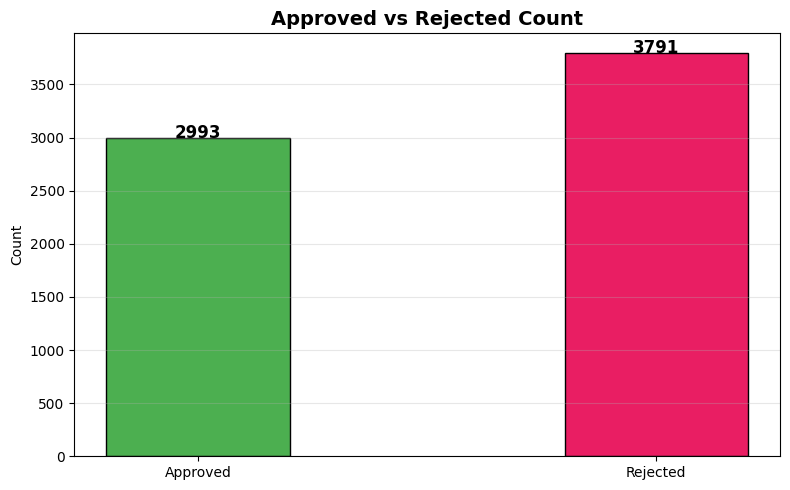

In [6]:
import matplotlib.pyplot as plt

# Approved vs Rejected Count
labels = ['Approved', 'Rejected']
values = [df['Approved'].value_counts()[1],
          df['Approved'].value_counts()[0]]
colors = ['#4CAF50', '#E91E63']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values,
               color=colors,
               width=0.4,
               edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.,
             height + 5,
             str(height),
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.title('Approved vs Rejected Count',
          fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Heatmap

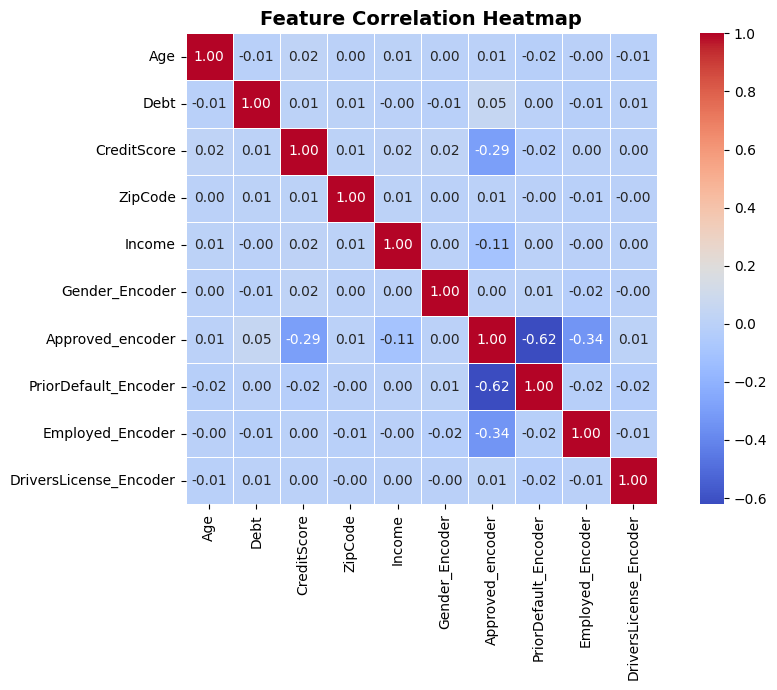

In [11]:
# Automatic — બધા numeric columns select કરે
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True)

plt.title('Feature Correlation Heatmap',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## Pie

C:\Users\A\AppData\Local\Temp\ipykernel_17372\3906972123.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.pie([sizes[0], sizes[1]],


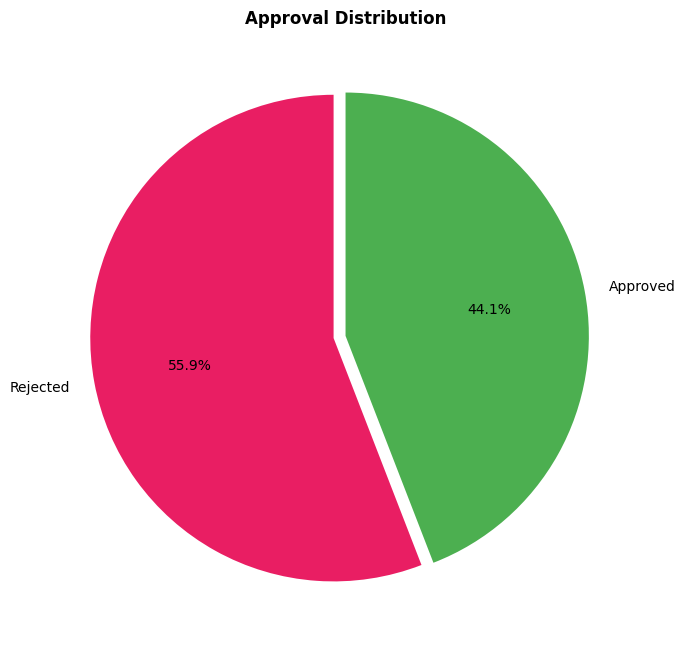

In [13]:

plt.figure(figsize=(7, 7))

sizes = df['Approved'].value_counts()
plt.pie([sizes[0], sizes[1]],
        labels=['Rejected', 'Approved'],
        colors=['#E91E63', '#4CAF50'],
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0))

plt.title('Approval Distribution',
          fontweight='bold')
plt.tight_layout()
plt.show()

## Scatter Plot

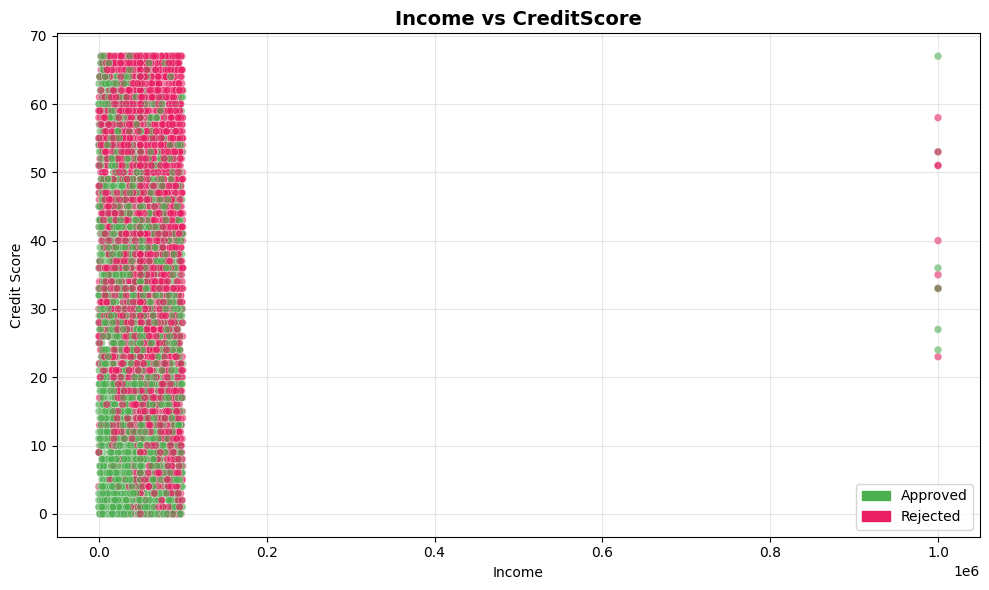

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import LabelEncoder

# ── Fresh Load ────────────────────────────────────────
df_orig = pd.read_csv('c:/Users/A/Intenship/Credit Card Approval Prediction System/clean_dataset.csv')

# ── Label Encoding Only ───────────────────────────────
le = LabelEncoder()
encode_cols = ['Gender_Encoder','Married','BankCustomer','Industry',
               'PriorDefault','Employed','DriversLicense',
               'Citizen','Approved_encoder']

for col in encode_cols:
    df_orig[col] = le.fit_transform(df_orig[col].astype(str))

# ── Scatter Plot ──────────────────────────────────────
colors = df_orig['Approved_encoder'].map({1:'#4CAF50', 0:'#E91E63'})

plt.figure(figsize=(10, 6))

plt.scatter(df_orig['Income'],
            df_orig['CreditScore'],
            c=colors,
            alpha=0.6,
            s=30,
            edgecolors='white',
            linewidths=0.3)

plt.title('Income vs CreditScore',
          fontsize=14, fontweight='bold')
plt.xlabel('Income')
plt.ylabel('Credit Score')
plt.grid(alpha=0.3)

# ── Legend ────────────────────────────────────────────
legend = [Patch(color='#4CAF50', label='Approved'),
          Patch(color='#E91E63', label='Rejected')]
plt.legend(handles=legend)

plt.tight_layout()
plt.show()

## Histogram

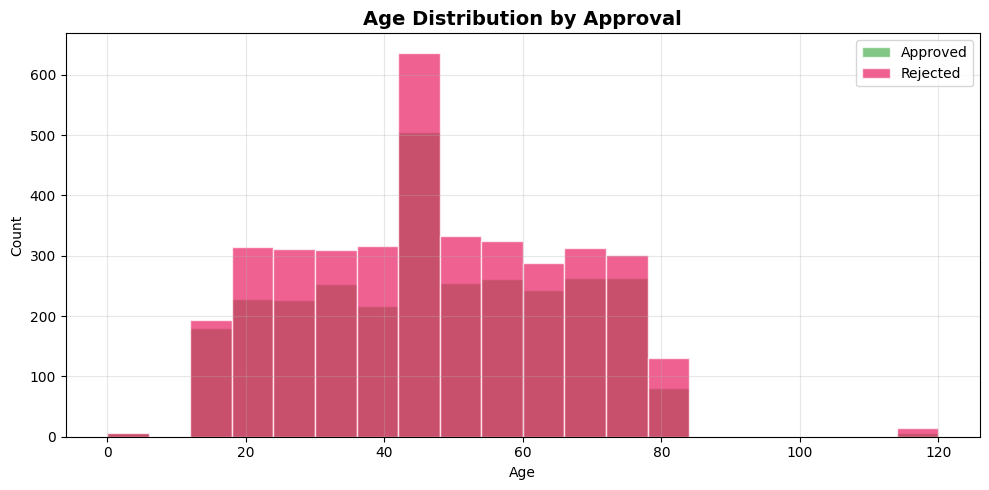

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(df_orig[df_orig['Approved_encoder']==1]['Age'],
         bins=20,
         color='#4CAF50',
         alpha=0.7,
         label='Approved',
         edgecolor='white')

plt.hist(df_orig[df_orig['Approved_encoder']==0]['Age'],
         bins=20,
         color='#E91E63',
         alpha=0.7,
         label='Rejected',
         edgecolor='white')

plt.title('Age Distribution by Approval',
          fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Pair Plot

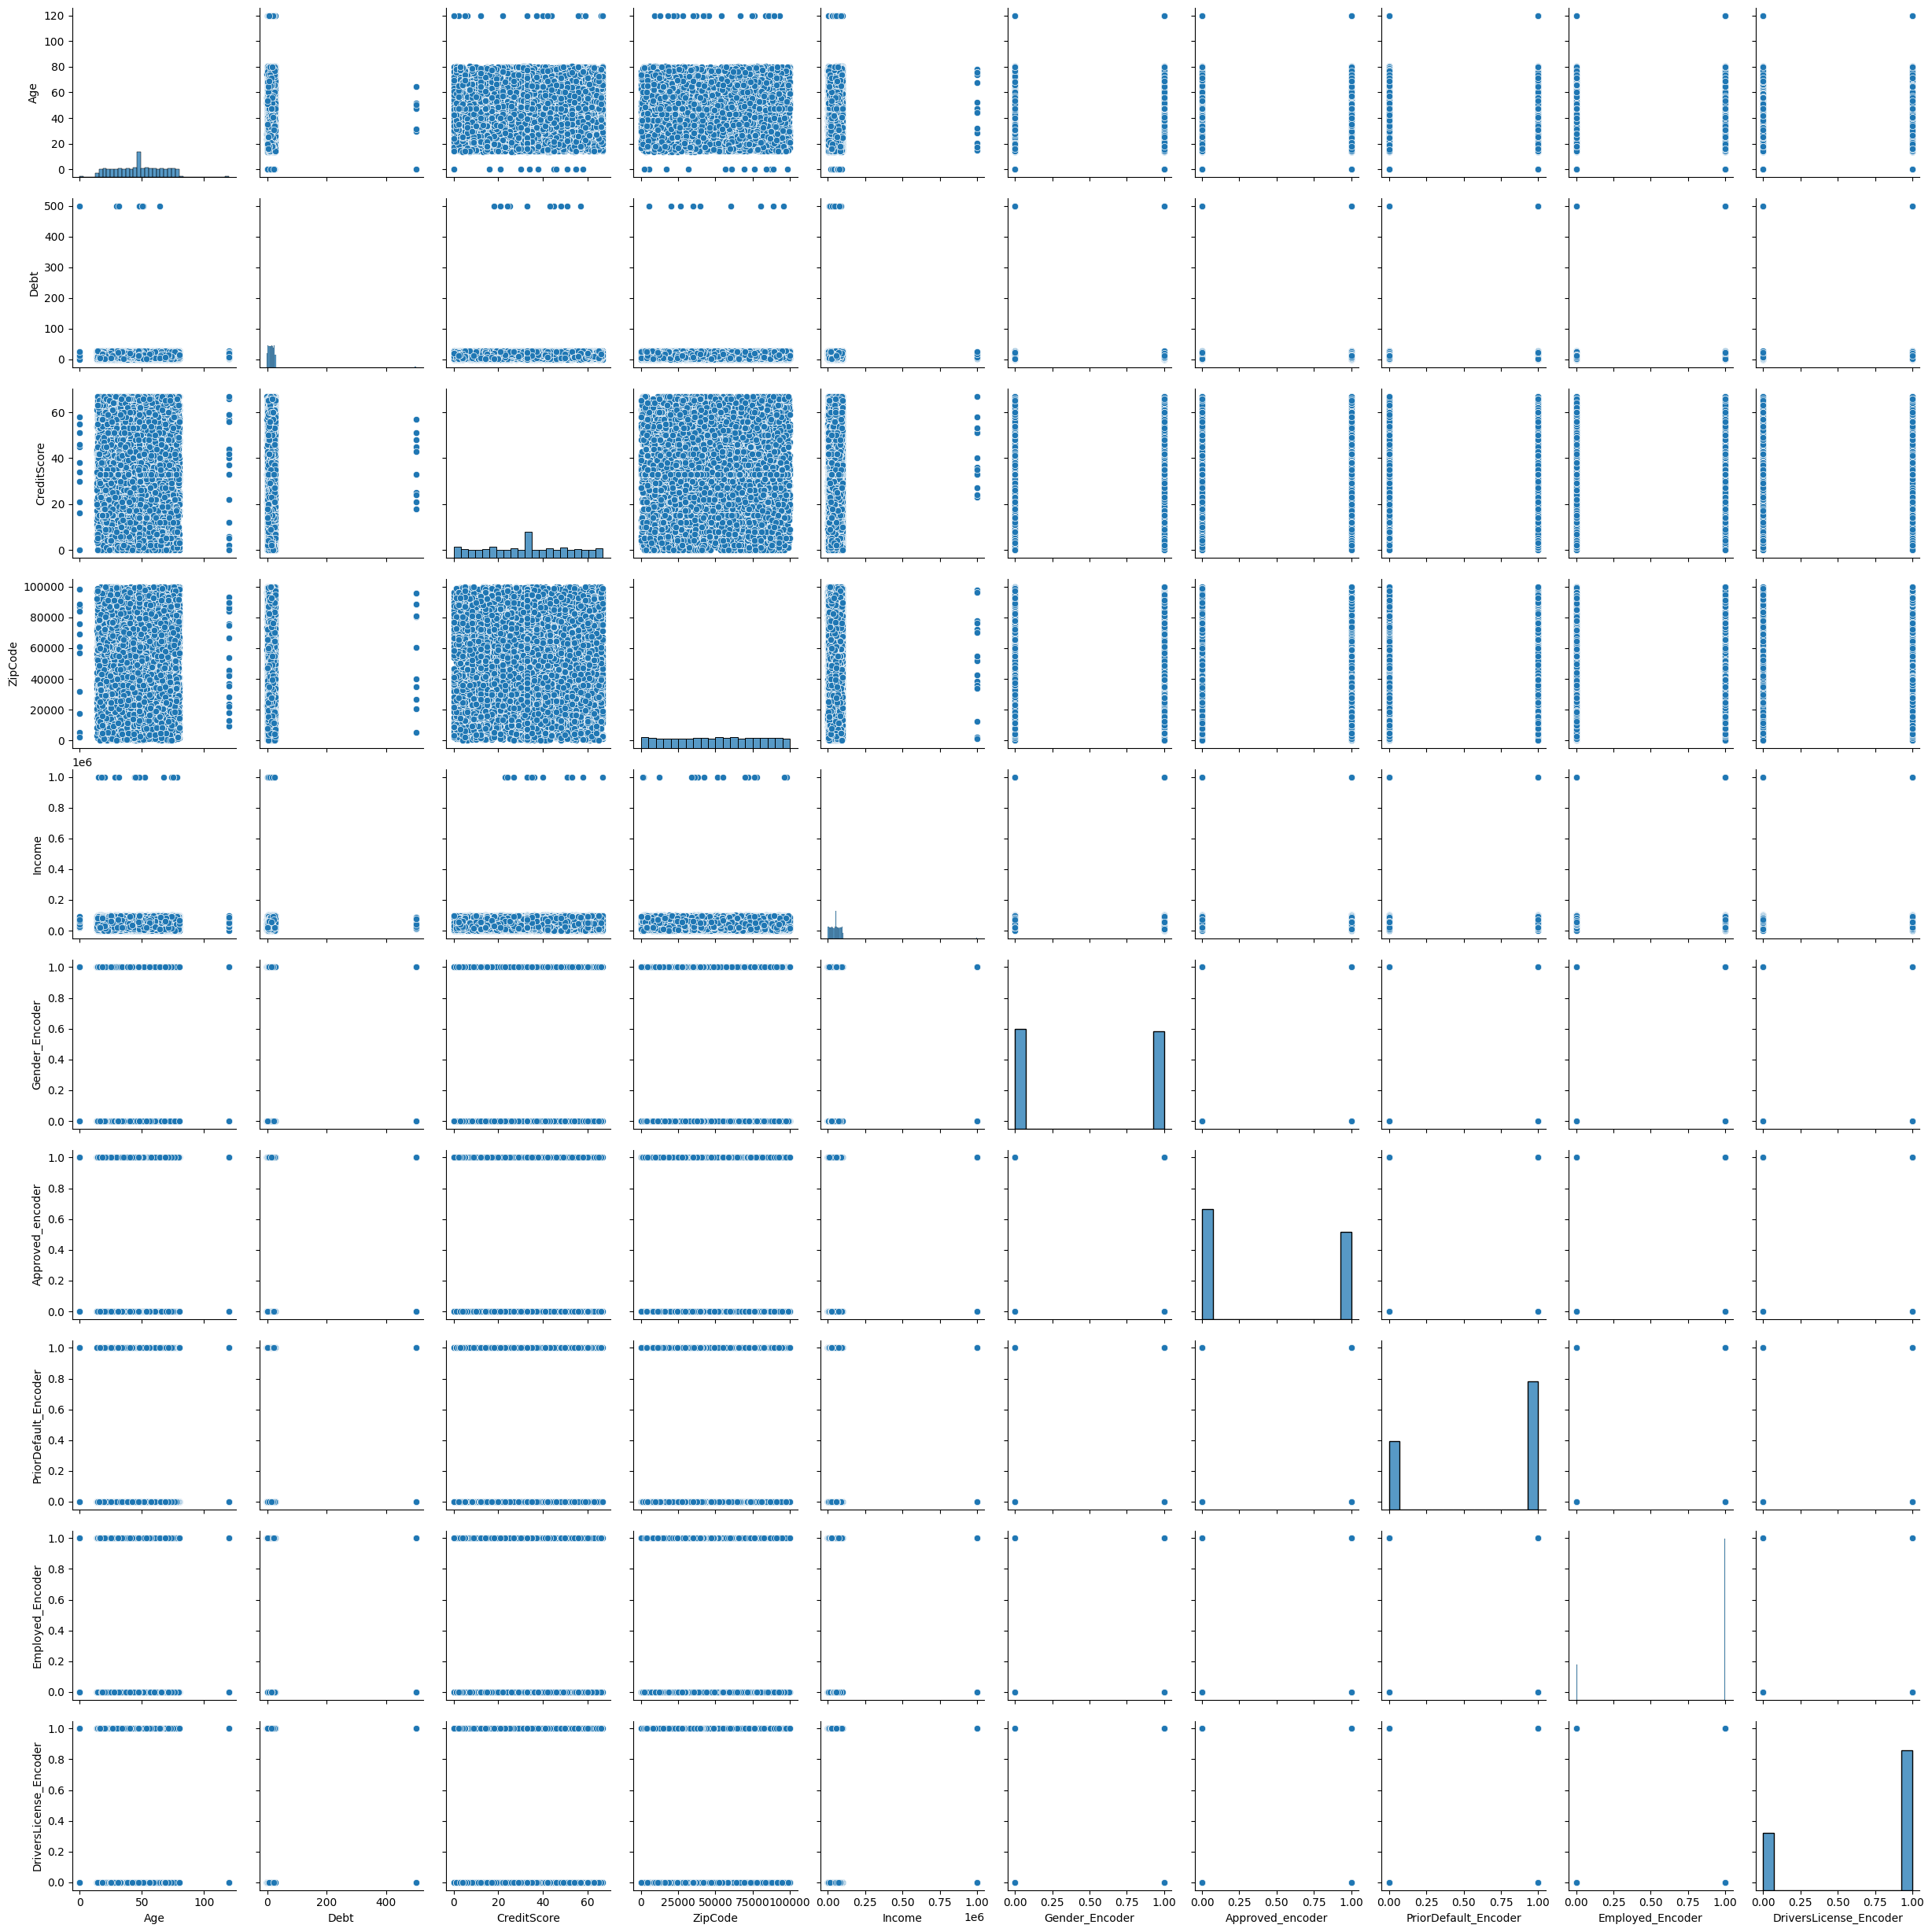

In [48]:
sns.pairplot(df)

## Violin Plot

C:\Users\A\AppData\Local\Temp\ipykernel_17372\1396960119.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Approved', y='Age', palette='pastel', split=True)


Text(0, 0.5, 'Age of Applicant')

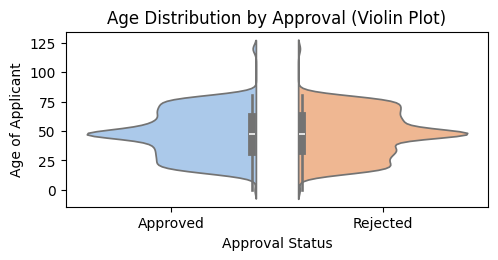

In [53]:
plt.subplot(2, 2, 1)
sns.violinplot(data=df, x='Approved', y='Age', palette='pastel', split=True)
plt.title('Age Distribution by Approval (Violin Plot)')
plt.xlabel('Approval Status') # X-axis Label
plt.ylabel('Age of Applicant')

## Area Plot

Text(0, 0.5, 'Income Amount')

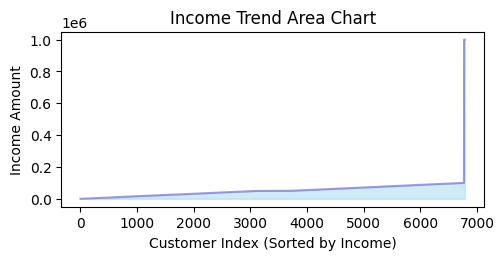

In [54]:
plt.subplot(2, 2, 2)
df_sorted = df.sort_values(by='Income').reset_index()
plt.fill_between(df_sorted.index, df_sorted['Income'], color="skyblue", alpha=0.4)
plt.plot(df_sorted.index, df_sorted['Income'], color="Slateblue", alpha=0.6)
plt.title('Income Trend Area Chart')
plt.xlabel('Customer Index (Sorted by Income)') 
plt.ylabel('Income Amount') 

## Box Plot

C:\Users\A\AppData\Local\Temp\ipykernel_17372\1968111984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Approved', y='CreditScore', palette='Set2')


Text(0, 0.5, 'Credit Score Value')

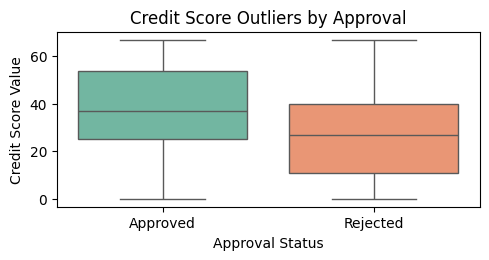

In [55]:
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Approved', y='CreditScore', palette='Set2')
plt.title('Credit Score Outliers by Approval')
plt.xlabel('Approval Status')
plt.ylabel('Credit Score Value')

## Line Chart

Text(0, 0.5, 'Debt Amount')

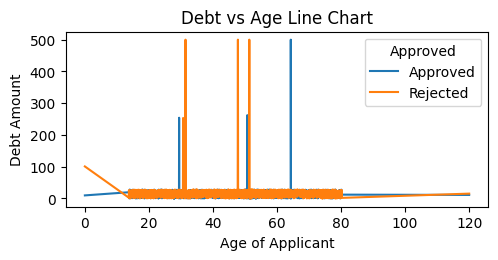

In [58]:
plt.subplot(2, 2, 4)
sns.lineplot(data=df, x='Age', y='Debt', hue='Approved', errorbar=None)
plt.title('Debt vs Age Line Chart')
plt.xlabel('Age of Applicant')
plt.ylabel('Debt Amount') 



## Bivariate KDE Plot

Text(0, 0.5, 'Debt Amount')

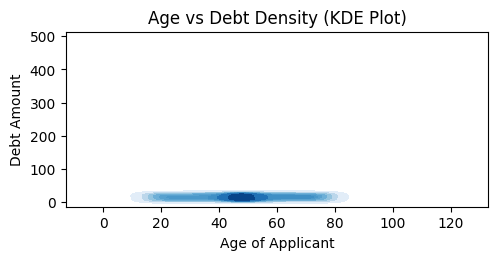

In [59]:
plt.subplot(2, 2, 2)
sns.kdeplot(data=df, x='Age', y='Debt', fill=True, cmap='Blues', thresh=0.05)
plt.title('Age vs Debt Density (KDE Plot)')
plt.xlabel('Age of Applicant')
plt.ylabel('Debt Amount')

## Strip Plot

Text(0, 0.5, 'Credit Score Value')

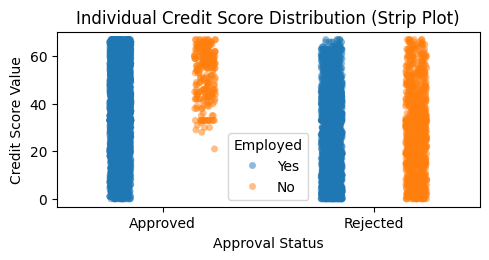

In [60]:
plt.subplot(2, 2, 3)
sns.stripplot(data=df, x='Approved', y='CreditScore', hue='Employed', jitter=True, alpha=0.5, dodge=True)
plt.title('Individual Credit Score Distribution (Strip Plot)')
plt.xlabel('Approval Status')
plt.ylabel('Credit Score Value')

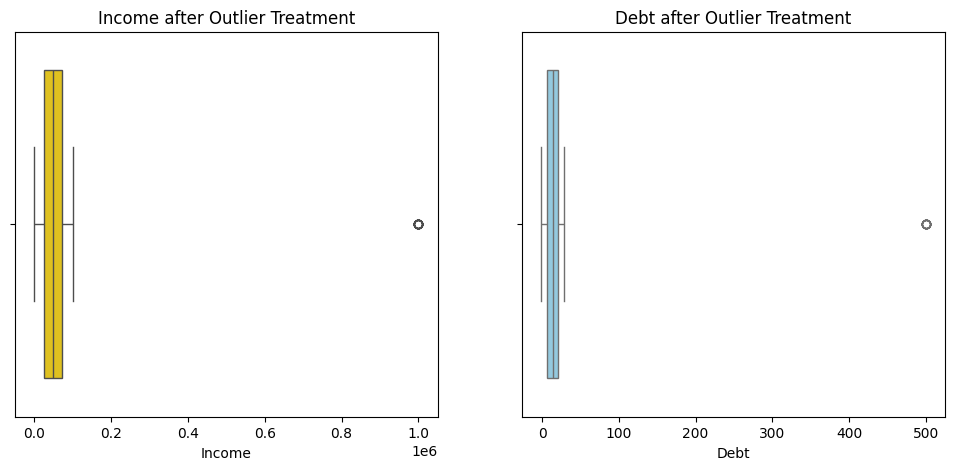

In [62]:
plt.figure(figsize=(12, 5))

# Income માટે બોક્સ પ્લોટ
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Income'], color='gold')
plt.title('Income after Outlier Treatment')

# Debt માટે બોક્સ પ્લોટ
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Debt'], color='skyblue')
plt.title('Debt after Outlier Treatment')

plt.show()